<h1><strong>Fake news verification solutions via agentic frameworks</strong></h1>

```
Author:
  Name:  Lorenzo Venturi
  Email: lorenzo.venturi14@studio.unibo.it
  ID:    0001138787

Professor: Gianluca Moro
Didactic Tutors:
- Dr. Giacomo Frisoni
- Dr. Lorenzo Molfetta
```

_Alma Mater Studiorum Università di Bologna_

**Course**: Big Data Analytics and Text Mining

**Project & project Work**

**This notebook aims to assess agents abilities in detecting fake claims.**

It contains 3 sections:
- **SECTION 1** - [_inspired by the workflow of this paper: [Large Language Model Agent for Fake News Detection](https://arxiv.org/pdf/2405.01593)_]: a **fixed** pipeline using LangGraph where a sequence of nodes analyze the claim from various perspectives. The effect of each node is assessed via an ablaton study.
- **SECTION 2** - [_inspired also by this paper: [Large Language Model Agent for Fake News Detection](https://arxiv.org/pdf/2405.01593)_]: a **non**-fixed pipeline where an agent built via LangChain decides which tools to call, and how many times.
- **SECTION 3** - [_inspired by this paper: [Debate-to-Detect: Reformulating Misinformation Detection as a
Real-World Debate with Large Language Models](https://arxiv.org/pdf/2505.18596)_] a **multi-agent** debate settings where two agents with distinct roles discuss between each other, implemented with LangGraph.

### Imports & Downloads

In [1]:
import gdown
import shutil
import os
import warnings
import re, signal

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import userdata

MAX_SEARCH_ITERATIONS=3

### Dataset download and preparation

Dataset credits: https://www.kaggle.com/datasets/rmisra/politifact-fact-check-dataset.
The data comes from a fact-checking website **PoliticFact** that evaluates the accuracy of claims made by elected officials, candidates, and political influencers.

In [2]:
dataset_repo = "./data/politifact"
os.makedirs(dataset_repo,exist_ok=True)

# folder drive with the dataset
folder_id = "https://drive.google.com/drive/folders/1dgtnH1NEI22GNxSal6qAbuJ4pUkPfVv2?usp=drive_link"
gdown.download_folder(id=folder_id,output=dataset_repo,quiet=False)

Retrieving folder contents


Processing file 1Dr9DZQ6nrED3UFY9THHmhfTxi4fhKqqu politifact_factcheck_data.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Dr9DZQ6nrED3UFY9THHmhfTxi4fhKqqu
To: /content/data/politifact/politifact_factcheck_data.json
100%|██████████| 9.84M/9.84M [00:00<00:00, 34.2MB/s]
Download completed


['./data/politifact/politifact_factcheck_data.json']

In [3]:
# dataset exploration
dataset_path=os.path.join(dataset_repo,'politifact_factcheck_data.json')
politicfact_dataset=pd.read_json(dataset_path,lines=True)
politicfact_dataset.head(5)

,verdict,statement_originator,statement,statement_date,statement_source,factchecker,factcheck_date,factcheck_analysis_link
0,true,Barack Obama,John McCain opposed bankruptcy protections for...,6/11/2008,speech,Adriel Bettelheim,6/16/2008,https://www.politifact.com/factchecks/2008/jun...
1,false,Matt Gaetz,"""Bennie Thompson actively cheer-led riots in t...",6/7/2022,television,Yacob Reyes,6/13/2022,https://www.politifact.com/factchecks/2022/jun...
2,mostly-true,Kelly Ayotte,"Says Maggie Hassan was ""out of state on 30 day...",5/18/2016,news,Clay Wirestone,5/27/2016,https://www.politifact.com/factchecks/2016/may...
3,false,Bloggers,"""BUSTED: CDC Inflated COVID Numbers, Accused o...",2/1/2021,blog,Madison Czopek,2/5/2021,https://www.politifact.com/factchecks/2021/feb...
4,half-true,Bobby Jindal,"""I'm the only (Republican) candidate that has ...",8/30/2015,television,Linda Qiu,8/30/2015,https://www.politifact.com/factchecks/2015/aug...


The dataset is composed of claims and different verdicts about the claim, we take a **subset** of the claim where the verdict is **TRUE** or **FALSE**.

I then build 2 subset to carry out the ablation study and the evaluation:
- for the ablation study: **30 fake claims - 30 true claims**
- for the evaluation study: **60 fake claims - 60 true claims**

In [4]:
# i extract true-false values
tf_dataset = politicfact_dataset[politicfact_dataset['verdict'].str.lower().isin(['true','false'])].copy()

false_df = tf_dataset[tf_dataset["verdict"].str.lower()=="false"]
true_df = tf_dataset[tf_dataset["verdict"].str.lower()=="true"]

# ablation subset
false_ablation_d = false_df.iloc[:30]
true_ablation_d  = true_df.iloc[:30]
ablation_dataset = pd.concat([false_ablation_d,true_ablation_d]).reset_index(drop=True)

# evaluation subset
false_evaluation = false_df.iloc[30:90]
true_evaluation  = true_df.iloc[30:90]
evaluation_dataset = pd.concat([false_evaluation,true_evaluation]).reset_index(drop=True)

#### External libraries download

In [5]:
%pip install \
  llama-index==0.14.15 \
  langgraph==1.0.10 \
  jedi==0.19.2 \
  accelerate==1.12.0 \
  pydantic==2.12.5 \
  langchain-ollama==1.0.1 \
  langchain_community==0.4.1 \
  langchain==1.2.10 \
  langchain-text-splitters==1.1.1 \
  langchain-core==1.2.16 \
  ddgs==9.11.1 \
  --quiet -q 2>/dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8

### Local Open Source LLMs with Ollama

In [6]:
!apt update -qq > /dev/null 2>&1 && apt install -y zstd curl > /dev/null 2>&1

In [7]:
!curl -fsSL https://ollama.com/install.sh | sh # the warnings that pops up are okay

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [8]:
import subprocess
import time
import requests

# we build a subprocess with ollama to run the LLMs on kaggles
process = subprocess.Popen(["ollama","serve"],
                          stdout=subprocess.DEVNULL,
                          stderr=subprocess.DEVNULL)
time.sleep(5)

try:
    response = requests.get("http://localhost:11434/api/tags",timeout=5)
    print(f"Ollama server status code: {response.status_code}")
except:
    print("Server failed")

Ollama server status code: 200


We download the models used for our project:

- **granite4:3b**  
  ~3B-parameter model by IBM, designed to handle general instruction-following tasks and suitable for integration into AI assistants across multiple domains, including business applications.

- **qwen3:4b**  
  ~4B-parameter model that delivers strong improvements in reasoning, instruction-following, and agent-oriented capabilities.

In [9]:
!ollama pull granite4:3b > /dev/null 2>&1

In [10]:
!ollama pull qwen3:4b > /dev/null 2>&1

In [11]:
!ollama list

NAME           ID              SIZE      MODIFIED               
qwen3:4b       359d7dd4bcda    2.5 GB    Less than a second ago    
granite4:3b    89962fcc7523    2.1 GB    32 seconds ago            


### Local LLM with Ollama

In [12]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Any
import operator
import torch
from langchain_ollama import ChatOllama
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', message='.*Impersonate.*')

In [13]:
llm = ChatOllama(
  model="granite4:3b",
  temperature=0, # i put to zero for reproducibility
  base_url="http://localhost:11434")

In [14]:
llm2 = ChatOllama(
  model="qwen3:4b",
  temperature=0, # i put to zero for reproducibility
  base_url="http://localhost:11434",
  reasoning=True)

# Section 1

## Fixed Workflow
- We use **LangGraph**, we build a **StateGraph**, a structure which has nodes that communicate by saving informations into a shared state.
- The StateGraph has a fixed number of nodes.
- Each node analyses the claim from a different perspective and expresses a single **vote**: `TRUE`, `FALSE`, or `NEUTRAL`.
- A final node aggregates all votes using a **majority voting** technique.

**Key machanism choice — vote-based aggregation:**  
The original paper approach used an expensive LLM api which consisted in a big model, that could handle an enormous context window.  
With my small 3B model building this big context causes **information overload**, which hurts the performance.
To build an optimized workflow, i approach the problem with a majority voting aggregation. Each node analyzes a different aspect of the news, and proceed to output a detection result.

Via an ablation study, i show that each node contributes at improving the final metrics, confirming the original paper propose of dividing the flow in mutliple steps.

**Nodes:**
1. **Check_markers**: vote based on fake-news markers (like: sensationalism, absolutism, conspiracy tone..)
2. **Source Credibility**: vote based on the originator type and reliability  
3. **Commonsense**: vote based on the LLM internal knowledge of plausibility of the news
4. **Intent**: vote based on whether the claim aims to inform vs inflame, the intention
5. **Search (fetch → eval loop)**: a two-step block that searches web evidence via DuckDuckGo and try to evaluate it. If the evaluation is inconclusive (`NEUTRAL`), the search is repeated with another query, up to a maximum of **3 iterations**. In the ablation study this block is treated as a single unit, search unit.
6. **Final Verdict**: apply the **majority vote** — `FALSE` only if FALSE votes strictly outnumber TRUE votes  

**Search API used:**
- **DuckDuckGo**: is a privacy-focused search API designed for LLM Agents.
  
---

### AgentState definition

AgentState is a serializable data object that serves as the shared memory for the agent. It keeps track of all analysis outputs across the execution graph, so the `final_verdict_node` can aggregate them.

In [15]:
class AgentState(TypedDict):
    claim: str  #the claim we want verify
    claim_date: str  #the date of when the claim was said
    claim_person:str  #who said the claim
    votes: dict # the votes expressed by the nodes
    search_articles:list
    search_links: list
    search_count:int  #tracks how many search iterations there have been
    search_queries:list #different searches that are tested
    search_log:list
    messages: Annotated[list,operator.add]
    results:dict

#### Generation

In [16]:
def generate(prompt:str,llm=None):
    """Call the LLM model with a specific prompt."""
    try:
        response = llm.invoke(prompt)
        if hasattr(response,'content'):
            return response.content
        else:
            return str(response)
    except Exception as e:
        return f"Error: {str(e)}"

#### Voting extracton mechanism

In [17]:
def extract_vote(llm_output:str)->str:
    """
    It extracts the final results of a node.
    Searches for the specific keyword from the llm text given in input.
    """
    upper_answer =llm_output.upper()
    for line in upper_answer.split("\n"):
        if "VOTE:" in line:
            after =line.split("VOTE:",1)[1].strip()
            if "FALSE" in after:
                return "FALSE"
            elif "TRUE" in after:
                return "TRUE"
            else:
                return "NEUTRAL"

### Node definitions

Each node asks the LLM a **single specific question** from a distinct perspective and extracts a **vote** (`TRUE` / `FALSE` / `NEUTRAL`).  
Votes are stored in `state["votes"]` and combined by a final verdict node via the majority voting.

The **Search** block is split into two nodes (`search_fetch` → `search_eval`) connected by a conditional edge that retries the search up to 3 times if the evaluation is `NEUTRAL`.

In [18]:
def check_markers_node(state: AgentState) -> AgentState:
    """
    This node tries to find classical fake-news language markers, as crazy words or strange ways to express it.
    """
    claim = state["claim"]
    claim_person = state["claim_person"]

    prompt_to_llm = f"""Analyse only the language and tone of this claim (ignore whether it is factually correct).

Claim: "{claim}"
Originator: "{claim_person}"

Check for these fake-news language markers:
- sensational words (like: BUSTED, SHOCKING, EXPOSED)
- absolute claims (like: 100%, ALWAYS, NEVER, NO ONE)
- conspiracy tone (like: cover-up, they don't want you to know)
- clickbait phrasing (like: ALL CAPS, teaser headlines)

Answer with one line:
VOTE: [TRUE/FALSE/NEUTRAL]"""

    output = generate(prompt_to_llm,llm)
    state["votes"]["check_markers"]=extract_vote(output)
    return state

In [19]:
def source_credibility_node(state: AgentState) -> AgentState:
    """
    This node evaluates the credibility of the person or entity who made the claim.
    """
    claim = state["claim"]
    claim_person = state["claim_person"]

    prompt = f"""You are a media-literacy expert. Evaluate ONLY who made this claim.

Claim: "{claim}"
Originator: "{claim_person}"

Consider:
- is the originator an anonymous blog, chain email, or social media post? → likely unreliable
- is the originator a known public figure with a mixed track record? → uncertain
- is the originator a verified official, institution, or journalist? → likely reliable

Based ONLY on source credibility:
If the source is clearly unreliable (anonymous, blog, chain email, known for false claims) → VOTE: FALSE
If the source is credible (verified official, institution, journalist) → VOTE: TRUE
If you cannot determine → VOTE: NEUTRAL

Answer with EXACTLY one line:
VOTE: [TRUE/FALSE/NEUTRAL]"""

    output = generate(prompt,llm)
    state["votes"]["source_credibility"]=extract_vote(output)
    return state

In [20]:
def commonsense_node(state:AgentState)->AgentState:
    """
    Node to check the plausibility of a claim using only the LLM internal knowledge.
    """
    claim = state["claim"]
    claim_date = state["claim_date"]

    prompt =f"""You are a fact-checker. Using your internal knowledge, judge this claim.

Claim: "{claim}"
Date: {claim_date}

Rules:
- If the claim clearly aligns with well-known, established facts → VOTE: TRUE
- If the claim clearly contradicts well-known facts, or is logically impossible → VOTE: FALSE
- If you are not sure, or the claim is too specific to verify from memory → VOTE: NEUTRAL
- IMPORTANT: when in doubt, say NEUTRAL — do NOT guess

Answer with EXACTLY one line:
VOTE: [TRUE/FALSE/NEUTRAL]"""

    output = generate(prompt,llm)
    state["votes"]["commonsense"] = extract_vote(output)
    return state

In [21]:
def intent_node(state: AgentState) -> AgentState:
    """
    Node used to classify the purpose of the claim, if it wants to provoke, it could be fake.
    """
    claim = state["claim"]
    claim_person = state["claim_person"]

    prompt_to_llm = f"""You are a communications analyst. Evaluate the PURPOSE of this claim.

Claim: "{claim}"
Originator: "{claim_person}"

- if this is a straightforward factual statement (sharing verifiable data, reporting events) → VOTE: TRUE
- if this is clearly designed to provoke outrage, fear, or distrust → VOTE: FALSE
- if you cannot clearly determine the intent → VOTE: NEUTRAL

Answer with EXACTLY one line:
VOTE: [TRUE/FALSE/NEUTRAL]"""

    output = generate(prompt_to_llm,llm)
    state["votes"]["intent"] = extract_vote(output)
    return state

In [22]:
def query_search_node(state:AgentState)->AgentState:
    """
    Node searches for web results for the claim using DuckDuckGo.
    It generates an optimized query and stores the results in the common state.
    If it is not the first iteration, i make the query different from the previous.
    """
    claim= state["claim"]
    claim_date =state["claim_date"]
    claim_person= state["claim_person"]
    before_queries =state.get("search_queries",[])
    n_search =state.get("search_count",0) + 1

    try:
        base_prompt = ("Extract an optimized web search query from this claim. Return only the query.")

        claim_values = f"""\nClaim: {claim}\nClaim date: {claim_date}\nClaim originator: {claim_person}"""

        if before_queries:
            prev_list = ""
            for q in before_queries:
                prev_list +=f"- {q}\n"

            query_prompt = f"""{base_prompt}
STRICT RULE: Write something different from this: {prev_list}.
{claim_values}.
Make sure to write a different query, even with a slight change. Absolutely not the same."""

        else:
            query_prompt = f"""{base_prompt}
            {claim_values}"""

        query_response=llm.invoke(query_prompt)
        if hasattr(query_response,"content"):
            search_query=query_response.content.strip()
        else:
            search_query=f"{claim} {claim_date}"

        before_queries.append(search_query)
        state["search_queries"]=before_queries

        # we do the search with the api, for a bug of the api with wikipedia i limit the search on us-en region
        wrapper = DuckDuckGoSearchAPIWrapper(region="us-en")
        search_engine=DuckDuckGoSearchResults(api_wrapper=wrapper,max_results=5,output_format="list")
        search_results=search_engine.run(search_query)

        articles,links=[],[]
        for item in search_results:
            link = item.get("link","")
            if "politifact" in link: # we skip ground truth value maybe coming from the dataset website
                continue
            articles.append(f"{item.get('title','No title')}: {item.get('snippet','No snippet')}")
            links.append(link)

        state["search_articles"]=articles
        state["search_links"]=links
        state["search_count"]=state.get("search_count",0)+1

        # i log the search values
        log = state.get("search_log",[])
        log.append({"round": n_search,
                    "query":search_query,
                    "articles":list(articles),
                    "links":list(links)})
        state["search_log"]=log

    except Exception as e: # if the search do not produce results, i skip
        state["search_articles"]=[]
        state["search_links"]=[]
        state["search_count"]=MAX_SEARCH_ITERATIONS

    return state


def search_evaluation_node(state:AgentState)->AgentState:
    """
    Search node evaluates the fetched web results and expresses a vote on them.
    If the node has not decided and search_count < MAX_SEARCH_ITERATIONS, i restart the search.
    """
    claim = state["claim"]
    articles=state.get("search_articles",[])
    n_search=state.get("search_count",0)

    if not articles:
        state["votes"]["search"]="NEUTRAL"
        log=state.get("search_log",[])
        if log:
            log[-1]["vote"]="NEUTRAL"
        return state

    search_summary=""
    for a in articles[:5]:
        search_summary += f"- {a}\n"

    search_summary=search_summary.rstrip()

    eval_prompt = f"""You are a fact-checker. Compare search results to the claim and cast a vote.

CLAIM: "{claim}"

SEARCH RESULTS:
{search_summary}

STRICT RULES:
- VOTE: FALSE only if a result EXPLICITLY debunks, disproves, or says the claim is false/misleading.
- VOTE: TRUE only if a result EXPLICITLY confirms the claim with evidence.
- VOTE: NEUTRAL in ALL other cases (unrelated results, vague, mixed, no mention of the claim).

Answer with EXACTLY one line:
VOTE: [TRUE/FALSE/NEUTRAL]"""

    output=generate(eval_prompt,llm)
    vote=extract_vote(output)
    state["votes"]["search"]=vote

    # i log the update
    log = state.get("search_log",[])
    if log:
        log[-1]["vote"]=vote

    return state


def repeat_search(state: AgentState) -> str:
    """
    Conditional edge, if the search node do not decide,repeat the search. Unitl we reach Max iterations.
    """
    vote = state.get("votes",{}).get("search","NEUTRAL")
    count = state.get("search_count",0)
    if vote == "NEUTRAL" and count<MAX_SEARCH_ITERATIONS:
        return "RETRY"
    return "DONE"

In [23]:
def final_verdict_node(state:AgentState) -> AgentState:
    """
    Node used for doing the final majority-vote aggregation.

    Voting rules:
    - Each node can answer TRUE,FALSE,or NEUTRAL (+1,-1,0)
    - I sum all the votes. If the total is < 0 → FALSE, else → TRUE.
    - If a news gets zero points, i say it is true (it is not proven as fake)
    """
    votes=state.get("votes",{})
    decision_score=0
    vote_specifics={}
    # i count the votes
    for node,vote in votes.items():
        if vote=="TRUE":
            decision_score+=1
            vote_specifics[node]="+1, detected as TRUE"
        elif vote=="FALSE":
            decision_score-=1
            vote_specifics[node]="-1, detected as FALSE"
        else:
            vote_specifics[node]="0, judge NEUTRAL"
    # we make the decision
    if decision_score<0:
        final_answer="FALSE"
    else:
        final_answer="TRUE"

    decision = f"The final score is={decision_score}. The news is predicted as: {final_answer}\n"
    for node,detail in vote_specifics.items():
        decision+= f"  {node}: {detail}\n"

    state["results"]["verdict"]=final_answer
    state["results"]["reasoning"]=decision
    state["results"]["vote_score"]=decision_score
    state["results"]["vote_specifics"]=vote_specifics

    return state

### Fixed full workflow definition

In [24]:
workflow_full=StateGraph(AgentState)

# node definitions
workflow_full.add_node("check_markers",check_markers_node)
workflow_full.add_node("source_credibility", source_credibility_node)
workflow_full.add_node("commonsense",commonsense_node)
workflow_full.add_node("intent", intent_node)
workflow_full.add_node("search_fetch",query_search_node)
workflow_full.add_node("search_eval", search_evaluation_node)
workflow_full.add_node("final_verdict",final_verdict_node)

# edges definitions
workflow_full.set_entry_point("source_credibility")
workflow_full.add_edge("source_credibility", "check_markers")
workflow_full.add_edge("check_markers","commonsense")
workflow_full.add_edge("commonsense","intent")
workflow_full.add_edge("intent","search_fetch")
workflow_full.add_edge("search_fetch", "search_eval")
workflow_full.add_conditional_edges(
    "search_eval",
    repeat_search,
    {
        "RETRY":"search_fetch",
        "DONE":"final_verdict"
    }
)
workflow_full.add_edge("final_verdict",END)

app_full=workflow_full.compile()

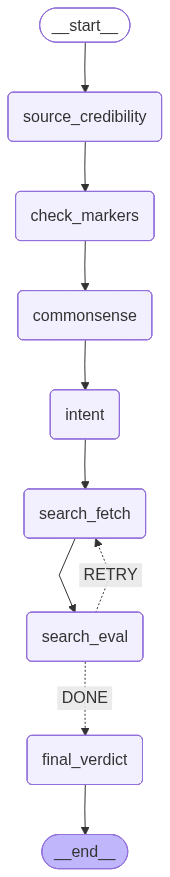

In [25]:
from IPython.display import display,Image
display(Image(app_full.get_graph().draw_mermaid_png(padding=100)))

### Test workflow execution

In [26]:
test_claim= evaluation_dataset.iloc[0]['statement']
test_claim_date =evaluation_dataset.iloc[0]['statement_date']
test_claim_person =evaluation_dataset.iloc[0]['statement_originator']
test_claim_ground_truth= evaluation_dataset.iloc[0]['verdict']

print(test_claim)
print(test_claim_date)
print(test_claim_person)
print(test_claim_ground_truth)

initial_state={
    "claim":test_claim,
    "claim_date":test_claim_date,
    "claim_person":test_claim_person,
    "votes":{},
    "search_articles":[],
    "search_links": [],
    "search_count": 0,
    "search_queries":[],
    "search_log":[],
    "messages":[],
    "results": {}
}

"Registered Republican not allowed to vote."
7/13/2020
Viral image
false


In [27]:
from IPython.display import display, HTML

def show(title,text,color):
    display(HTML(f"""<div style="border-left:4px solid {color}; padding:8px 12px; margin:4px 0; background:#f9f9f9;">
                     <h3 style="color:{color};">{title}</h3><br>
                     <span style="font-size:15px;">{str(text).replace(chr(10),'<br>')}</span> </div>"""))

In [28]:
result =app_full.invoke(initial_state)

show("Claim",test_claim,"#FFA500")

colors={"TRUE":"#16a34a",
        "FALSE":"#dc2626",
        "NEUTRAL":"#6b7280"}

for node,vote in result.get("votes",{}).items():
    color=colors.get(vote,"#6b7280")
    show(f"Vote: {node}",vote,color)

for entry in result.get("search_log",[]):
    round_num =entry["round"]
    query =entry["query"]
    articles =entry.get("articles",[])
    links =entry.get("links",[])
    vote=entry.get("vote"," ")

    results = f"Query: {query}\n\n results ({len(articles)}):\n"
    for i,(article,link) in enumerate(zip(articles,links),1):
        results += f"  {i} {article}\n {link}\n"
    results += f"\nVote: {vote}"

    vote_color = colors.get(vote,"#6b7280")
    show(f"Search Round {round_num}",results,vote_color)

if "verdict" in result["results"]:
    color = "#16a34a"
    if result["results"]["verdict"]=="FALSE":
        color= "#dc2626"
    show("Final Verdict",result["results"]["reasoning"],color)

#### Evaluation definition

In [29]:
from tqdm import tqdm
import time
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix,ConfusionMatrixDisplay

In [30]:
def pipeline_evaluation(app, dataset):
    """
    Function i use to iterate over the dataset, run the fixed pipeline for each claim, and collect the predictions.
    """
    results =[]
    wrong_indices =[]

    for idx,row in tqdm(dataset.iterrows(),total=len(dataset)):
        claim = row['statement']
        claim_date = row['statement_date']
        claim_person = row['statement_originator']
        ground_truth = row['verdict'].upper()

        initial_state ={
            "claim":claim,
            "claim_date":claim_date,
            "claim_person":claim_person,
            "votes":{},
            "search_articles":[],
            "search_links":[],
            "search_count":0,
            "search_queries":[],
            "search_log":[],
            "messages":[],
            "results":{}
        }

        try:
            result=app.invoke(initial_state)
            predicted_answer = result["results"].get("verdict","UNCERTAIN").upper()

            correct = predicted_answer==ground_truth
            if not correct:
                wrong_indices.append(idx)

            results.append({
                'claim':claim,
                'ground_truth':ground_truth,
                'predicted':predicted_answer,
                'correct':correct,
                'reasoning':result["results"].get("reasoning"," "),
                'votes':dict(result.get("votes",{}))
            })

        except Exception as e:
            print(f"Error {e}")

    results_df = pd.DataFrame(results)
    return results_df

In [31]:
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score

def compute_metrics(results_df):
    y_true = results_df['ground_truth']
    y_pred = results_df['predicted']

    f1 = f1_score(y_true,y_pred,average="macro")
    accuracy = accuracy_score(y_true,y_pred)
    recall = recall_score(y_true,y_pred,average="macro")
    precision = precision_score(y_true,y_pred,average="macro")

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score MACRO: {f1:.2f}")

    labels = sorted(y_true.unique())
    conf_mat = confusion_matrix(y_true,y_pred,labels=labels)
    fig,ax = plt.subplots(figsize=(5,4))
    sns.heatmap(conf_mat,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels,ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

### Ablation study

#### 1 - Baseline: check_markers+Source Credibility
We start from 2 initial nodes, in order to have the voting mechanism.

In [32]:
workflow_1 = StateGraph(AgentState)

workflow_1.add_node("source_credibility",source_credibility_node)
workflow_1.add_node("check_markers",check_markers_node)
workflow_1.add_node("final_verdict", final_verdict_node)

workflow_1.set_entry_point("check_markers")
workflow_1.add_edge("check_markers","source_credibility")
workflow_1.add_edge("source_credibility","final_verdict")
workflow_1.add_edge("final_verdict",END)

app_1 =workflow_1.compile()

In [33]:
results_df_1 = pipeline_evaluation(app_1,ablation_dataset)

100%|██████████| 60/60 [00:34<00:00,  1.74it/s]


Accuracy: 0.58
Precision: 0.62
Recall: 0.58
F1-score MACRO: 0.55


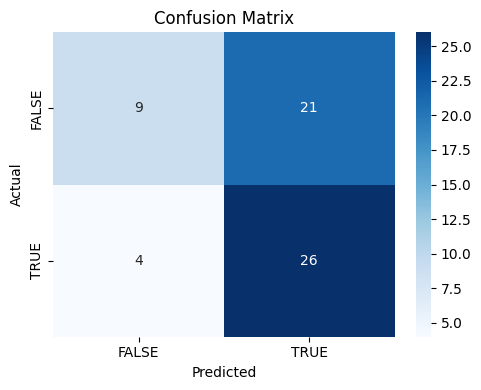

In [34]:
compute_metrics(results_df_1)

#### 2 - + Commonsense

In [35]:
workflow_2 = StateGraph(AgentState)

workflow_2.add_node("check_markers", check_markers_node)
workflow_2.add_node("source_credibility", source_credibility_node)
workflow_2.add_node("commonsense", commonsense_node)
workflow_2.add_node("final_verdict", final_verdict_node)

workflow_2.set_entry_point("source_credibility")
workflow_2.add_edge("source_credibility","check_markers")
workflow_2.add_edge("check_markers","commonsense")
workflow_2.add_edge("commonsense","final_verdict")
workflow_2.add_edge("final_verdict", END)

app_2 =workflow_2.compile()

In [36]:
results_df_2 =pipeline_evaluation(app_2,ablation_dataset)

100%|██████████| 60/60 [00:52<00:00,  1.14it/s]


Accuracy: 0.63
Precision: 0.69
Recall: 0.63
F1-score MACRO: 0.61


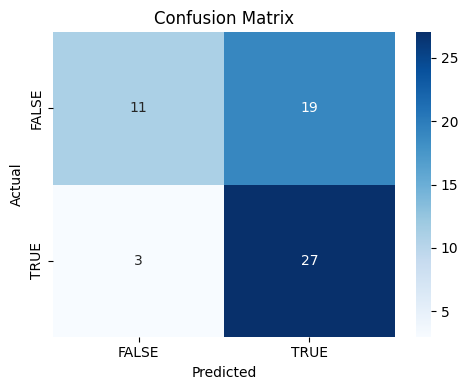

In [37]:
compute_metrics(results_df_2)

#### 3 - + Intent

In [38]:
workflow_3 = StateGraph(AgentState)

workflow_3.add_node("check_markers", check_markers_node)
workflow_3.add_node("source_credibility", source_credibility_node)
workflow_3.add_node("commonsense", commonsense_node)
workflow_3.add_node("intent", intent_node)
workflow_3.add_node("final_verdict", final_verdict_node)

workflow_3.set_entry_point("source_credibility")
workflow_3.add_edge("source_credibility", "check_markers")
workflow_3.add_edge("check_markers", "commonsense")
workflow_3.add_edge("commonsense", "intent")
workflow_3.add_edge("intent", "final_verdict")
workflow_3.add_edge("final_verdict", END)

app_3 = workflow_3.compile()

In [39]:
results_df_3 =pipeline_evaluation(app_3,ablation_dataset)

100%|██████████| 60/60 [01:09<00:00,  1.16s/it]


Accuracy: 0.65
Precision: 0.65
Recall: 0.65
F1-score MACRO: 0.65


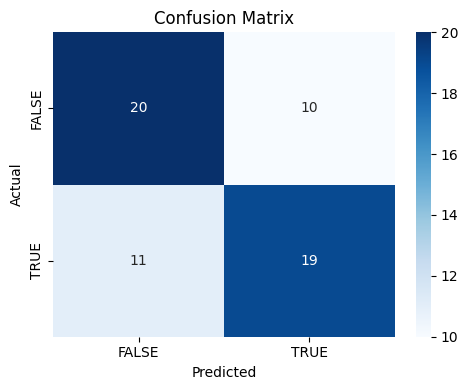

In [40]:
compute_metrics(results_df_3)

#### 4 - + Search (full pipeline)

In [41]:
workflow_4 = StateGraph(AgentState)

workflow_4.add_node("check_markers", check_markers_node)
workflow_4.add_node("source_credibility", source_credibility_node)
workflow_4.add_node("commonsense", commonsense_node)
workflow_4.add_node("intent", intent_node)
workflow_4.add_node("search_fetch", query_search_node)
workflow_4.add_node("search_eval", search_evaluation_node)
workflow_4.add_node("final_verdict", final_verdict_node)

workflow_4.set_entry_point("source_credibility")
workflow_4.add_edge("source_credibility", "check_markers")
workflow_4.add_edge("check_markers", "commonsense")
workflow_4.add_edge("commonsense", "intent")
workflow_4.add_edge("intent", "search_fetch")
workflow_4.add_edge("search_fetch","search_eval")
workflow_4.add_conditional_edges(
    "search_eval",
    repeat_search,
    {
        "RETRY":"search_fetch",
        "DONE":"final_verdict"
    }
)
workflow_4.add_edge("final_verdict",END)
app_4 = workflow_4.compile()

In [42]:
results_df_4= pipeline_evaluation(app_4,ablation_dataset)

100%|██████████| 60/60 [08:16<00:00,  8.27s/it]


Accuracy: 0.68
Precision: 0.68
Recall: 0.68
F1-score MACRO: 0.68


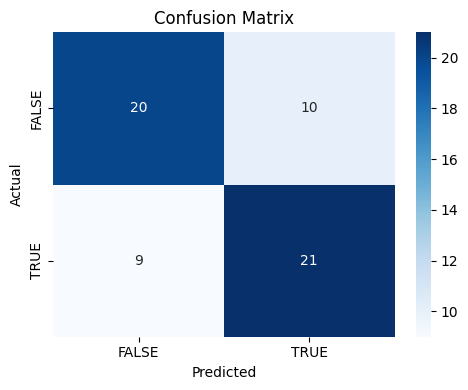

In [43]:
compute_metrics(results_df_4)

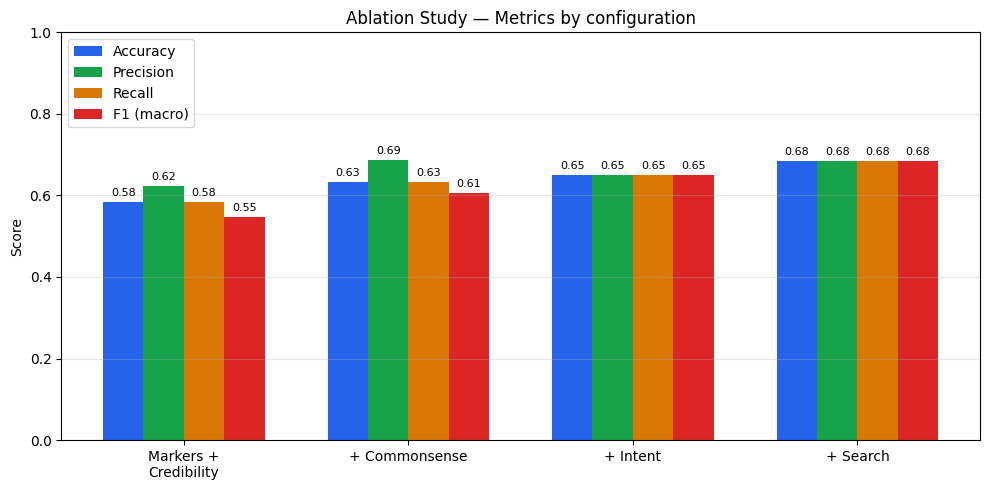

In [44]:
ablation_labels = [
    "Markers +\nCredibility",
    "+ Commonsense",
    "+ Intent",
    "+ Search"
]

ablation_ds = [results_df_1,results_df_2,results_df_3,results_df_4]

metrics_collection = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 (macro)": []}

for df in ablation_ds:
    y_true,y_pred = df["ground_truth"],df["predicted"]
    metrics_collection["Accuracy"].append(accuracy_score(y_true,y_pred))
    metrics_collection["Precision"].append(precision_score(y_true,y_pred,average="macro"))
    metrics_collection["Recall"].append(recall_score(y_true,y_pred,average="macro"))
    metrics_collection["F1 (macro)"].append(f1_score(y_true,y_pred,average="macro"))

x = np.arange(4)
width = 0.18
colors = ["#2563eb","#16a34a","#d97706","#dc2626"]

fig,ax = plt.subplots(figsize=(10,5))
for i,(metric,values) in enumerate(metrics_collection.items()):
    bars = ax.bar(x + i * width,values,width,label=metric,color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Ablation Study — Metrics by configuration")
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(ablation_labels)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_study_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

### Full fixed pipeline evaluation

In [45]:
results_df_full = pipeline_evaluation(app_full,evaluation_dataset)

100%|██████████| 120/120 [15:36<00:00,  7.81s/it]


Accuracy: 0.74
Precision: 0.74
Recall: 0.74
F1-score MACRO: 0.74


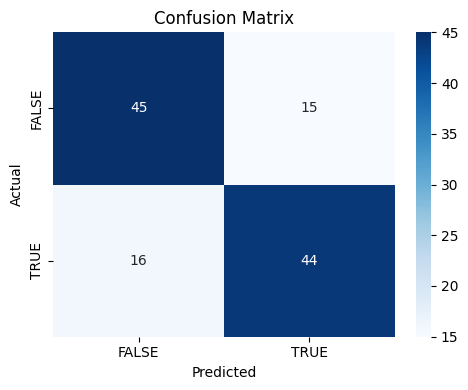

In [46]:
compute_metrics(results_df_full)

# Section 2

## Variable Workflow
- Via **LangChain**, i define an agent that decides **autonomously** which tools to call.
- The tools are defined in a similar way to the Fixed Workflow implementation.
- The agent can decide to call the same tool multiple times if it is not sure about the outcome.
- An initial `system_prompt` is given to the agent to explain what it should do.

**Tools:**
- **Check_markers**: check a claim for fake-news language markers (sensationalism, absolutes, conspiracy tone)
- **Source Credibility**: evaluate the originator's credibility and reliability
- **Commonsense**: check if the claim is reasonable or contradicts known facts  
- **Intent**: analyse whether the claim aims to inform vs inflame  
- **Search**: search the web for information about the claim and decide accordingly

The tools documentation is key as the agent will read it.

**Search Api used:**
- **DuckDuckGo**: privacy-focused search API designed for LLM Agents

**I limit the number of tools callable otherwise the time to run is not sustainable for the evaluation set**

In [47]:
from langgraph.prebuilt import ToolNode
from llama_index.core.tools import FunctionTool
from typing import Dict

from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import StructuredTool

from langchain.agents.middleware import SummarizationMiddleware, TodoListMiddleware, ContextEditingMiddleware

### Tools definition

In [48]:
def check_markers_tool(claim:str) -> str:
    """
    Tool to analyse the claim for fake-news language markers such as sensationalism, absolutism and conspiracy tone.

    Args:
        claim: the claim to check
    """
    prompt = f"""Analyse ONLY the language and tone of this claim (ignore whether it is factually correct).

Claim: "{claim}"

Check for these fake-news language markers:
- sensational words (like BUSTED, SHOCKING, EXPOSED)
- absolute claims (like 100%, ALWAYS, NEVER, NO ONE)
- conspiracy tone (like cover-up, they don't want you to know)
- clickbait phrasing (like ALL CAPS, teaser headlines)

If 2 or more markers are clearly present the claim is likely fake.
If 0-1 markers the claim language appears normal.
If uncertain, state that.

Keep your response in one sentence."""

    analysis = generate(prompt,llm)
    return f"check_markers ANALYSIS:\n{analysis}"

In [49]:
def source_credibility_tool(claim: str, claim_person: str) -> str:
    """
    Evaluate the credibility and reliability of the claim's originator.

    Args:
        claim: the claim to check
        claim_person: who made the claim
    """
    prompt = f"""You are a media-literacy expert. Evaluate ONLY who made this claim.

Claim: "{claim}"
Originator: "{claim_person}"

Consider:
- is the originator an anonymous blog, chain email, or social media post? → likely unreliable
- is the originator a known public figure with a mixed track record? → uncertain
- is the originator a verified official, institution, or journalist? → likely reliable

Provide a one sentence credibility assessment."""

    analysis = generate(prompt,llm)
    return f"SOURCE CREDIBILITY CHECK:\n{analysis}"

In [50]:
def commonsense_tool(claim: str, claim_date: str = "") -> str:
    """
    Evaluate if claim is reasonable and consistent with common sense and established facts based on LLM internal knowledge.

    Args:
        claim: the claim to check
        claim_date: the date of the claim (optional)
    """
    prompt = f"""You are a balanced fact-checker. Using your internal knowledge, judge this claim.

Claim: "{claim}"
Date: {claim_date}

Rules:
- If the claim aligns with well-known, established facts → likely TRUE
- If the claim contradicts well-known facts, or is logically impossible → likely FALSE
- If you are not sure → state that you are uncertain
- Many political and factual claims ARE true — do not assume false by default

Provide a one sentence reasoned assessment."""

    analysis = generate(prompt,llm)
    return f"COMMONSENSE CHECK:\n{analysis}"

In [51]:
def intent_tool(claim: str, claim_person: str = "") -> str:
    """
    Used to classify the purpose of the claim, if informative or inflammatory.

    Args:
        claim: the claim to check
        claim_person: who made the claim (optional)
    """
    prompt = f"""You are a communications analyst. Evaluate the PURPOSE of this claim.

Claim: "{claim}"
Originator: "{claim_person}"

- if this is a straightforward factual statement (sharing verifiable data, reporting events) → likely true
- if this is clearly designed to provoke outrage, fear, or distrust → likely inflammatory
- if you cannot clearly determine the intent → state that you are uncertain

Provide a brief assessment."""

    analysis = generate(prompt,llm)
    return f"INTENT ANALYSIS:\n{analysis}"

In [52]:
def search_tool(claim: str, claim_date:str, claim_person: str) -> str:
    """
    Search the web for information about the claim.
    Useful for finding external verification or contradicting information.

    Args:
        claim: the claim to check
        claim_date: the claim date
        claim_person: the originator of the claim
    """
    try:
        # i generate an optimized search query using the LLM
        query_prompt = f"""Extract an optimized web search query from this claim.
Claim: {claim}
Claim date: {claim_date}
Claim originator: {claim_person}
Return only the search query, nothing else."""

        query_response = llm.invoke(query_prompt)

        if hasattr(query_response,'content'):
            search_query=query_response.content.strip()
        else:
            search_query=claim

        # run the search
        wrapper = DuckDuckGoSearchAPIWrapper(region="us-en")
        search_engine=DuckDuckGoSearchResults(api_wrapper=wrapper,max_results=5,output_format="list")
        search_results=search_engine.run(search_query)

        articles,links = [],[]
        for item in search_results:
            link=item.get('link','')
            if 'politifact' in link:  # i skip politifact links to avoid data leakage
                continue
            articles.append(f"{item.get('title','No title')}: {item.get('snippet','No snippet')}")
            links.append(link)

        if not articles:
            return "SEARCH RESULTS: no findings"

        # i combine the search results
        search_summ=""

        for articl,link in zip(articles,links):
            search_summ+=f"{articl}\nSource: {link}\n\n"

        # the prompt to evaluate the search
        eval_prompt = f"""Evaluate these search results for fact-checking the claim.
CLAIM: {claim}
SEARCH RESULTS:
{search_summ}

Be balanced: look equally for evidence that SUPPORTS and evidence that CONTRADICTS the claim.
- If results confirm the claim with evidence → assessment: SUPPORTS
- If results explicitly debunk or disprove the claim → assessment: CONTRADICTS
- If results are unrelated or inconclusive → assessment: UNCLEAR
Provide your assessment (SUPPORTS, CONTRADICTS, or UNCLEAR) with a one sentence explanation."""

        evaluation = generate(eval_prompt,llm)

        return f"SEARCH RESULTS:\n{search_summ}\nSEARCH EVALUATION:\n{evaluation}"

    except Exception as e:
        return f"Error during search: {str(e)}"

In [53]:
# we collect all the tools defined
tools = [check_markers_tool,source_credibility_tool,commonsense_tool,intent_tool,search_tool]

In [54]:
# we convert the functions tools to LangChain tools using @tool decorator style
lc_tools = [
    StructuredTool.from_function(func=check_markers_tool,name="check_markers_tool",description=check_markers_tool.__doc__),
    StructuredTool.from_function(func=source_credibility_tool,name="source_credibility_tool", description=source_credibility_tool.__doc__),
    StructuredTool.from_function(func=commonsense_tool,name="commonsense_tool", description=commonsense_tool.__doc__),
    StructuredTool.from_function(func=intent_tool,name="intent_tool", description=intent_tool.__doc__),
    StructuredTool.from_function(func=search_tool,name="search_tool",description=search_tool.__doc__),
]

In [55]:
# system prompt-> initial promt to guide the agent behavior
system_prompt = """You are a balanced fact-checking agent. Determine whether a claim is TRUE or FALSE.

TOOL RULES:
- Call only the tools you find necessary for the specific claim.
- You may call the same tool more than once if needed (maximum 3 times).
- Stop calling tools as soon as you have enough evidence.
- Do NOT exceed 5 tool calls total per claim.

VERDICT RULES:
- If evidence SUPPORTS the claim → VERDICT: TRUE
- If evidence CONTRADICTS the claim → VERDICT: FALSE
- If evidence is mixed or unclear, say TRUE

Provide your final verdict on a single line:
VERDICT: TRUE
or
VERDICT: FALSE
Followed by ONE sentence of explanation."""

### Variable workflow Test - Reasoning active

We build a reactive agent (since some months, create_react_agent was moved into langchain.agents import create_agent).

The **middleware** part are reusable, plug-and-play functions that intercept and modify an agent’s input/output during execution, in particular we use:
- **SummarizationMiddleware**: manages conversation history to prevent hitting token limits (context overflow)
- **TodoListMiddleware**: enables agents to plan, track, and manage multi-step, complex tasks by providing structured task management capabilities
- **ContextEditingMiddleware**: manage the "brain space" (context) by pruning or editing large tool outputs that might otherwise clutter the agent's reasoning

In [56]:
agent_reasoning = create_agent(
    model=llm2, # qwen reasoning on
    tools=lc_tools,
    system_prompt=system_prompt,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("tokens",4000),
            keep=("messages",20),
            summary_prompt="Custom prompt for summarization..."
        ),
        TodoListMiddleware(),
        ContextEditingMiddleware(
            token_count_method="approximate"
        )
    ]
)

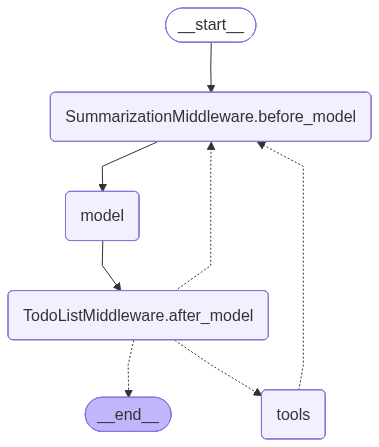

In [57]:
from IPython.display import display,Image

png_data = agent_reasoning.get_graph().draw_mermaid_png(padding=100)
display(Image(agent_reasoning.get_graph().draw_mermaid_png(padding=100)))

In [58]:
from IPython.display import display, HTML

def show(title, text, color):
    display(HTML(f"""<div style="border-left:4px solid {color}; padding:8px 12px; margin:4px 0; background:#f9f9f9;">
                     <b style="color:{color};">{title}</b><br>
                     <span style="font-size:13px;">{str(text).replace(chr(10),'<br>')}</span> </div>"""))

In [59]:
test_claim= evaluation_dataset.iloc[0]['statement']
test_claim_date =evaluation_dataset.iloc[0]['statement_date']
test_claim_person =evaluation_dataset.iloc[0]['statement_originator']
test_claim_ground_truth= evaluation_dataset.iloc[0]['verdict']

print(test_claim)
print(test_claim_date)
print(test_claim_person)
print(test_claim_ground_truth)

"Registered Republican not allowed to vote."
7/13/2020
Viral image
false


In [60]:
input_payload={
    "messages":[
        {
            "role": "user",
            "content": (
                "Fact-check the following claim.\n\n"
                f"Claim: {test_claim}\n"
                f"Claim originator: {test_claim_person}\n"
                f"Claim date: {test_claim_date}"
            )
        }
    ]
}

In [61]:
def fact_check_verbose(claim:str):
    """
    This is used to call and extract from the agent the process, tool, answers..
    """
    reasoning_memory = ""
    ai_memory = ""

    show("Claim",claim,"#2563eb")

    for chunk,metadata in agent_reasoning.stream(
         input_payload,
         stream_mode="messages"
        ):

        if hasattr(chunk,'additional_kwargs') and chunk.additional_kwargs:
            reasoning_token = chunk.additional_kwargs.get('reasoning_content','')

            if reasoning_token:
                reasoning_memory+=reasoning_token

        if chunk.type=="AIMessageChunk":
            if chunk.content:
                ai_memory += chunk.content
            if chunk.tool_call_chunks:
                for tc in chunk.tool_call_chunks:
                    if tc.get("name"):
                        if ai_memory.strip():
                            show("Response",ai_memory.strip(),"#475569")
                            ai_memory=""
                        show("Calling Tool",tc['name'],"#d97706")

        elif chunk.type=="tool":
            show(f"Tool Result [{chunk.name}]",chunk.content,"#059669")

    if reasoning_memory.strip():
        show("Reasoning", reasoning_memory.strip(),"#7c3aed")
    if ai_memory.strip():
        show("Response", ai_memory.strip(),"#475569")

fact_check_verbose(test_claim+ " "+str(test_claim_date))

### Full Variable Workflow Evaluation

In [62]:
agent = create_agent(
    model=llm, #granite
    tools=lc_tools,
    system_prompt=system_prompt,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("tokens",4000),
            keep=("messages",20),
            summary_prompt="Custom prompt for summarization..."
        ),
        TodoListMiddleware(),
        ContextEditingMiddleware(
            token_count_method="approximate"
        )
    ]
)

In [63]:
def react_pipeline_evaluation(agent,dataset,timeout=120):
    """
    Function to evaluate the agent on the dataset.
    Streams each agent response, tool count, collects the final text output, and parses the TRUE/FALSE verdict.
    To not risk to get stuck i set a timeout limit.
    """
    # timeout handling
    signal.signal(signal.SIGALRM,
                  lambda s,f: (_ for _ in ()).throw(TimeoutError()))

    results = []
    tool_called=[]
    for idx,row in tqdm(dataset.iterrows(),total=len(dataset)):
        claim = row['statement']
        claim_date = row['statement_date']
        claim_person=row['statement_originator']
        ground_truth = row['verdict'].upper()

        full_content = ""
        claim_tool_called = []

        input_payload={"messages":[{
                                    "role": "user",
                                    "content": (
                                    "Fact-check the following claim.\n\n"
                                    f"Claim: {claim}\n"
                                    f"Claim originator: {claim_person}\n"
                                    f"Claim date: {claim_date}")}]}

        try:
            signal.alarm(timeout)
            for chunk,metadata in agent.stream(
                input_payload,
                stream_mode="messages"
                ):

                if chunk.type=="AIMessageChunk" and chunk.content:
                    if isinstance(chunk.content, list):
                        for block in chunk.content:
                            if isinstance(block, str):
                                full_content += block
                            elif isinstance(block, dict) and block.get("type")=="text":
                                full_content+=block.get("text","")
                    else:
                        full_content+=chunk.content

                if chunk.type == "tool" and hasattr(chunk,"name"):
                    claim_tool_called.append(chunk.name)

            signal.alarm(0)
            tool_called.extend(claim_tool_called)

            verdict = "FALSE"
            # i extract from the final answer the TRUE or FALSE
            match=re.search(r'VERDICT\s*:\s*(TRUE|FALSE)',full_content,re.IGNORECASE)
            if match:
                verdict = match.group(1).upper()
            elif "VERDICT" in full_content.upper(): # if regex fail, i search in the entire answer
                for line in full_content.split("\n"):
                    if "VERDICT" in line.upper():
                        if "TRUE" in line.upper() and "FALSE" not in line.upper():
                            verdict = "TRUE"
                        elif "FALSE" in line.upper():
                            verdict = "FALSE"
                        break

            results.append({
                'claim':claim,
                'ground_truth':ground_truth,
                'predicted':verdict,
                'correct':verdict == ground_truth,
                'reasoning':full_content,
                'tools_called':claim_tool_called
            })

        except Exception as e:
            signal.alarm(0)
            results.append({
                'claim': claim,
                'ground_truth': ground_truth,
                'predicted': "FALSE",
                'correct': "FALSE" == ground_truth,
                'reasoning': f"exception: {e}",
                'tools_called': claim_tool_called
            })

    results_df=pd.DataFrame(results)


    return results_df,tool_called

In [80]:
react_results_df,all_tool_called=react_pipeline_evaluation(agent,evaluation_dataset)

100%|██████████| 120/120 [48:32<00:00, 24.27s/it]


Accuracy: 0.63
Precision: 0.70
Recall: 0.63
F1-score MACRO: 0.60


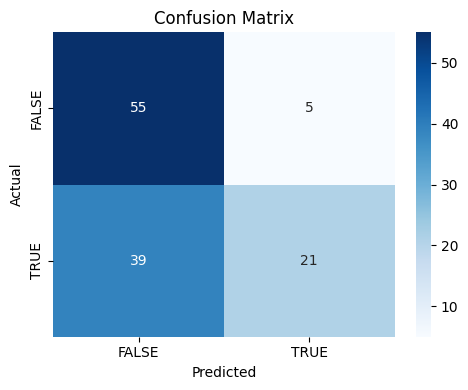

In [81]:
compute_metrics(react_results_df)

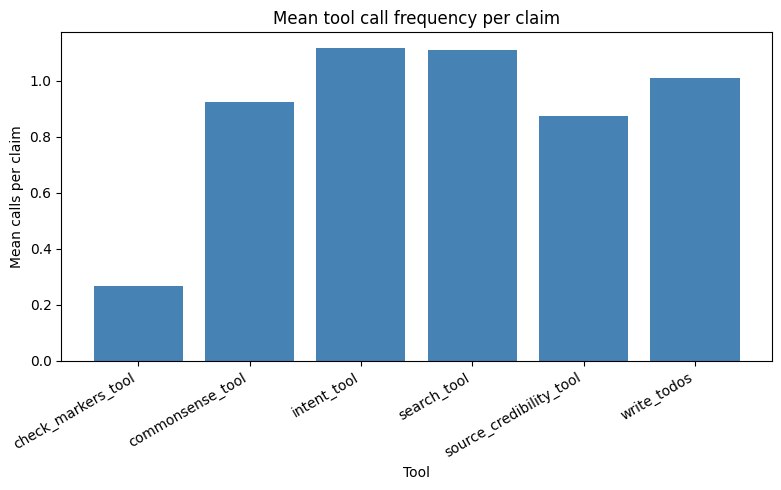

In [82]:
import numpy as np

tool_counts=react_results_df["tools_called"].apply(Counter)

all_tools=set()
for c in tool_counts:
    all_tools.update(c.keys())

mean_calls = {}
for tool in sorted(all_tools):
    val=[]
    for c in tool_counts:
        val.append(c.get(tool,0))
    mean_calls[tool] = np.mean(val)

plt.figure(figsize=(8,5))
plt.bar(mean_calls.keys(),mean_calls.values(),color='steelblue')
plt.xlabel("Tool")
plt.ylabel("Mean calls per claim")
plt.title("Mean tool call frequency per claim")
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.savefig("mean_tool_calls.png", dpi=300, bbox_inches="tight")
plt.show()

# Section 3
## Agent debate for Fake News Verification

We build an architecture composed like that:
- **Affermative Agent** : instructed to explain why the claim is correct
- **Negative Agent** : instructed to explain why the claim is wrong
- **Judge Agents** : instructed to decide whether to make the debate continue or stop the conversation and decide the winner

### Workflow

<pre><code>
Negative_Node → Affirmative_Node → Judge_Node ──┐
       ↑                                        │
       └─────────── CONTINUE ───────────────────┤
                                                │
                    STOP → END ─────────────────┘
</code></pre>

In [67]:
from langgraph.graph import StateGraph,END
from typing import TypedDict,List

In [68]:
llm_debate = ChatOllama(
  model="granite4:3b",
  temperature=1, # i put 1 for variability in the conversation, this makes results not strictly reproducible.
  base_url="http://localhost:11434")

In [69]:
# Common state definition
class Debate_State(TypedDict):
    claim: str
    history: list
    last_message:str
    debate_round: int
    stop:bool
    verdict:str

In [70]:
def Generate_For_Debate(role, message):
    """
    Function for generation for the two debating agents"""
    system_prompt = f"You are a {role}. Given the debate history, answer shortly to the topic in your own perspective."

    response = llm_debate.invoke([
        {"role":"system","content":system_prompt},
        {"role":"user","content":message}])

    if hasattr(response,'content'):
        return response.content
    else:
        return str(response)

In [71]:
def Negative_Node(state:Debate_State):
    """
    This is the node of the agent that go against the claim, stating it as fake.
    """
    transcript = ""
    for role,mex in state["history"]:
        transcript += f"{role}: {mex}\n"
    if not transcript:
        transcript ="No arguments yet."

    msg =Generate_For_Debate(
        role="negative debater who argues against the claim",
        message=(
            f"Claim: {state['claim']}\n\n"
            f"Debate history so far:\n{transcript}\n\n"
            f"Opponent's last argument: {state['last_message']}\n\n"
            "Give a NEW perspective to respond to the last message, do not repeat what was already said.")).strip()

    state["history"].append(("Negative_Agent",msg))
    state["last_message"]=msg
    return state

In [72]:
def Affirmative_Node(state:Debate_State):
    """
    This is the node of the agent that go pro the claim, stating it as true.
    """
    transcript = ""
    for role,mex in state["history"]:
        transcript+=f"{role}: {mex}\n"
    if not transcript:
        transcript="No arguments yet."

    msg = Generate_For_Debate(
        role="affirmative debater who argues in favour of the claim",
        message=(
            f"Claim: {state['claim']}\n\n"
            f"Debate history so far:\n{transcript}\n\n"
            f"Opponent's last argument: {state['last_message']}\n\n"
            "Give a NEW perspective to respond to the last message, do not repeat what was already said.")).strip()

    state["history"].append(("Affirmative_Agent", msg))
    state["last_message"] = msg
    state["debate_round"] += 1
    return state

In [73]:
MAX_ROUNDS = 4

In [74]:
def Judge_Node(state: Debate_State):
    transcript = ""
    for role,mex in state["history"]:
        transcript+=f"{role}: {mex}\n"
    if not transcript:
        transcript="No arguments yet."

    # if it reaches max rounds stops
    if state["debate_round"] >= MAX_ROUNDS:
        state["stop"] = True
    else:
        decision = Generate_For_Debate(
            role="impartial judge evaluating a debate",
            message=(
                f"Claim being debated: {state['claim']}\n\n"
                f"Debate so far:\n{transcript}\n\n"
                "Decide whether the debate should continue or stop.\n"
                "Stop if, giving the arguments, you know who is right.\n"
                "Answer only with CONTINUE or STOP.")).strip().upper()
        state["stop"] = "STOP" in decision

    if state["stop"]:
        verdict_raw= Generate_For_Debate(
            role="impartial judge delivering the final verdict",
            message=(
                f"Claim being debated: {state['claim']}\n\n"
                f"Full debate transcript:\n{transcript}\n\n"
                "Based on the debate above and on general knowledge, is the claim TRUE or FALSE?\n"
                "Answer only with TRUE or FALSE.")).strip().upper()
        state["verdict"]="TRUE" if "TRUE" in verdict_raw else "FALSE"

    return state

### Graph definition

In [75]:
graph = StateGraph(Debate_State)

graph.add_node("Affirmative_Node",Affirmative_Node)
graph.add_node("Negative_Node",Negative_Node)
graph.add_node("Judge_Node",Judge_Node)

graph.set_entry_point("Negative_Node")

graph.add_edge("Negative_Node", "Affirmative_Node")
graph.add_edge("Affirmative_Node", "Judge_Node")

# node which decides if or not repeat the process
graph.add_conditional_edges(
    "Judge_Node",
    lambda state: "STOP" if state["stop"] else "CONTINUE",
    {
        "CONTINUE": "Negative_Node",
        "STOP": END
    }
)

debate_graph = graph.compile()

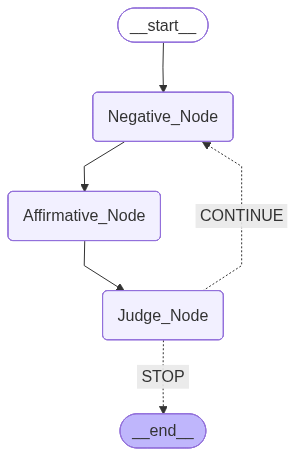

In [76]:
from IPython.display import display,Image

display(Image(debate_graph.get_graph().draw_mermaid_png(padding=100)))

### Test

In [77]:
topic = evaluation_dataset.iloc[0]['statement']

initial_state = {
    "claim": topic,
    "history": [],
    "last_message": f"The debate topic is this claim: {topic}",
    "debate_round": 0,
    "stop": False,
    "verdict": ""
}

print(f"CLAIM: {topic}\n{'='*80}")

for step in debate_graph.stream(initial_state,stream_mode="updates"):
    for node,node_state in step.items():
        if node == "Negative_Node":
            last = node_state["history"][-1]
            print(f"\n[Round {node_state['debate_round']+1}] NEGATIVE\n {last[1]}")
        elif node == "Affirmative_Node":
            last = node_state["history"][-1]
            print(f"\n[Round {node_state['debate_round']}] AFFIRMATIVE\n {last[1]}")
        elif node == "Judge_Node":
            if node_state["stop"]:
                decision = "STOP"
            else:
                decision = "CONTINUE"

            print(f"\n  → JUDGE: {decision}")

final_state = node_state
print(f"\n{'='*60}")
print(f"Debate ended after {final_state['debate_round']} round(s).")
print(f"FINAL VERDICT: {final_state['verdict']}")

CLAIM: "Registered Republican not allowed to vote."

[Round 1] NEGATIVE
 Registered Republicans, like any other eligible voters, should have the right to vote without any restrictions or barriers imposed on their political affiliation. It is crucial to uphold the principles of democracy and ensure that every eligible citizen has the opportunity to participate in the electoral process. Any attempt to restrict the voting rights of registered Republicans would be a violation of their fundamental democratic rights and could undermine the integrity of the entire voting system.

[Round 1] AFFIRMATIVE
 Registered Republicans, like all other citizens, should have equal and unrestricted access to the polls to cast their vote in accordance with the law. Any attempt to limit or deny their right to vote would be a blatant affront to democratic values and the Constitution. It is essential that all eligible voters, regardless of their political leanings, are able to exercise their franchise without 

### Full Debate Workflow Evaluation

In [78]:
debate_results = []

for idx,row in tqdm(evaluation_dataset.iterrows(),total=len(evaluation_dataset)):
    claim=row['statement']
    ground_truth=row['verdict'].upper()

    initial_state = {
        "claim":claim,
        "history":[],
        "last_message": f"The debate topic is this claim: {claim}",
        "debate_round": 0,
        "stop": False,
        "verdict":""
    }

    try:
        result = debate_graph.invoke(initial_state)
        predicted = result["verdict"]
    except Exception as e:
        predicted = "TRUE"

    debate_results.append({
        "claim": claim,
        "ground_truth": ground_truth,
        "predicted": predicted,
        "correct": predicted == ground_truth,
        "rounds": result.get("debate_round", 0)
    })

debate_df=pd.DataFrame(debate_results)

100%|██████████| 120/120 [55:55<00:00, 27.96s/it]


Accuracy: 0.68
Precision: 0.70
Recall: 0.68
F1-score MACRO: 0.68


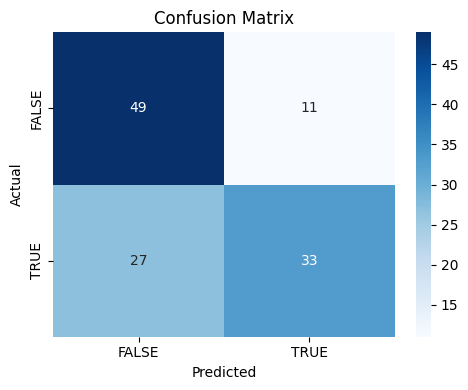

In [79]:
compute_metrics(debate_df)

# Results Comparison

| Metric    | Pipeline 1 | Pipeline 2 | Pipeline 3 |
|-----------|------------|------------|------------|
| Precision |   0.74     |     0.70       |     0.70       |
| Recall    |   0.74     |     0.63       |       0.68     |
| Accuracy  |   0.74     |     0.63       |       0.68     |
| F1-score  |   0.74     |     0.60       |       0.68     |

The three solutions aim to capture different techniques proposed in recent literature to address fake news in an agentic manner.  
Each technique has its own pros and cons, which are summarized below.

### Fixed Pipeline

**Pros**
- Works well with small models, as each sub-task is manageable and short.
- Lower runtime compared to the other two techniques, since the LLM only needs to output a final decision (fewer output tokens) and the steps are fixed.

**Cons**
- Treating each node as equally important in the majority voting mechanism can be a limitation. In many cases, specific nodes may identify a decisive factor for determining the truthfulness of a claim, yet they are given the same weight as others.

### Variable Pipeline

**Pros**
- Allowing the LLM to decide which tools to call often reduces the total number of nodes executed.
- With a large LLM, this approach would likely strongly outperform the Fixed Pipeline baseline.

**Cons**
- With limited GPU resources and smaller models, performance is significantly lower compared to the Fixed Pipeline.

### Debate Pipeline

**Pros**
- The discussion process can encourage the LLM to reason in different ways, potentially leading to better results.

**Cons**
- The limited context window of smaller models (such as the one used) restricts the reasoning capabilities of the debate, as the model must retain past conversational context to derive new insights.

### Main Limitations of the Experiments

- Limited GPU time, which led to a reduced dataset size.
- Limited LLM model size.